### Create bed file for bedtools analysis and .txt list of SNPs for PLINK

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt 
import seaborn as sns
from adjustText import adjust_text

In [2]:
Jurgens_GWAS_loci = pd.read_csv("Jurgens_GWAS_hits_GRCh38.bed", delim_whitespace=True, header=None)

In [3]:
Jurgens_GWAS_loci.columns = ["chr", "start", "end", "rsID", "candidate_gene", "total_score"]
Jurgens_GWAS_loci['study'] = "Jurgens"
Jurgens_GWAS_loci.head()
print(f"Number of SNPs: {Jurgens_GWAS_loci.shape[0]}")

Number of SNPs: 65


In [4]:
Jurgens_GWAS_loci

,chr,start,end,rsID,candidate_gene,total_score,study
0,chr1,2212668,2212668,rs2503715,SKI,2,Jurgens
1,chr1,6203732,6203732,rs11121483,RNF207,3,Jurgens
2,chr1,16012430,16012430,rs1763605,HSPB7,2,Jurgens
3,chr1,45544980,45544980,rs518365,MAST2,2,Jurgens
4,chr1,51327586,51327586,rs72694111,CDKN2C,1,Jurgens
...,...,...,...,...,...,...,...
60,chr19,45855699,45855699,rs113996837,SYMPK,2,Jurgens
61,chr20,35002555,35002555,rs4616,GSS,1,Jurgens
62,chr21,29157810,29157810,rs62222424,BACH1,2,Jurgens
63,chr21,39272244,39272244,rs8134638,BRWD1,2,Jurgens


In [5]:
Zheng_GWAS_loci = pd.read_csv("Zheng_GWAS_hits_GRCh38.bed", delim_whitespace=True, header=None)
Zheng_GWAS_loci.columns = ["chr", "start", "end", "rsID", "candidate_gene", "total_score"]
Zheng_GWAS_loci['study'] = "Zheng"
Zheng_GWAS_loci.head()
print(f"Number of SNPs: {Zheng_GWAS_loci.shape[0]}")

Number of SNPs: 104


In [6]:
Zheng_GWAS_loci

,chr,start,end,rsID,candidate_gene,total_score,study
0,chr1,2212668,2212668,rs2503715,C1orf86,1,Zheng
1,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng
2,chr1,6218354,6218354,rs709209,RNF207,3,Zheng
3,chr1,16013277,16013277,rs1763604,HSPB7,4,Zheng
4,chr1,16018235,16018235,rs945418,HSPB7,4,Zheng
...,...,...,...,...,...,...,...
99,chr20,35046676,35046676,rs13042358,TRPC4AP,2,Zheng
100,chr21,29199348,29199348,rs8134232,BACH1,2,Zheng
101,chr21,29157810,29157810,rs62222424,BACH1,2,Zheng
102,chr21,38657121,38657121,rs796217035,ERG,3,Zheng


In [7]:
combined_GWAS_loci_df = pd.concat([Jurgens_GWAS_loci, Zheng_GWAS_loci])
combined_GWAS_loci_df.head()
print(combined_GWAS_loci_df.shape)

(169, 7)


In [8]:
counts_per_GWAS_loci = combined_GWAS_loci_df.groupby('rsID')['chr'].count().reset_index()
intersecting_SNPs = counts_per_GWAS_loci[counts_per_GWAS_loci['chr'] > 1]['rsID'].tolist()
print(f"Number of exact intersecting SNPs: {len(intersecting_SNPs)}")

Number of exact intersecting SNPs: 12


In [9]:
# unique to Jurgens
filt_Jurgens_GWAS_loci = Jurgens_GWAS_loci[~Jurgens_GWAS_loci['rsID'].isin(intersecting_SNPs)].copy()

# unique to Zheng
filt_Zheng_GWAS_loci = Zheng_GWAS_loci[~Zheng_GWAS_loci['rsID'].isin(intersecting_SNPs)].copy()

# found in both
both_study_GWAS_loci = Jurgens_GWAS_loci[Jurgens_GWAS_loci['rsID'].isin(intersecting_SNPs)].copy()
both_study_GWAS_loci['study'] = 'both'

## For rs2503715, update candidate as both SKI (Jurgens) and C1orf86 (Zheng)
both_study_GWAS_loci.loc[both_study_GWAS_loci['rsID'] == "rs2503715", 'candidate_gene'] = "SKI_or_C1orf86"

In [10]:
unique_combined_GWAS_loci_df = pd.concat([filt_Jurgens_GWAS_loci, filt_Zheng_GWAS_loci, both_study_GWAS_loci])
unique_combined_GWAS_loci_df.shape

(157, 7)

### Save the file with effector genes

In [11]:
unique_combined_GWAS_loci_df["chr_num"] = (
    unique_combined_GWAS_loci_df["chr"]
    .str.replace("chr", "", regex=False)
    .replace({"X": 23, "Y": 24, "M": 25})   # handle sex chromosomes/mito if present
    .astype(int)
)
    
unique_combined_GWAS_loci_df = unique_combined_GWAS_loci_df.sort_values(
    by=["chr_num", "start", "end"]
).drop(columns="chr_num")

In [12]:
unique_combined_GWAS_loci_df.head(10)

,chr,start,end,rsID,candidate_gene,total_score,study
0,chr1,2212668,2212668,rs2503715,SKI_or_C1orf86,2,both
1,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng
1,chr1,6203732,6203732,rs11121483,RNF207,3,Jurgens
2,chr1,6218354,6218354,rs709209,RNF207,3,Zheng
2,chr1,16012430,16012430,rs1763605,HSPB7,2,Jurgens
3,chr1,16013277,16013277,rs1763604,HSPB7,4,Zheng
4,chr1,16018235,16018235,rs945418,HSPB7,4,Zheng
3,chr1,45544980,45544980,rs518365,MAST2,2,Jurgens
5,chr1,45555958,45555958,rs2993263,MAST2,2,Zheng
4,chr1,51327586,51327586,rs72694111,CDKN2C,1,Jurgens


In [13]:
# sort by candidate_gene, chr, start
unique_combined_GWAS_loci_df = unique_combined_GWAS_loci_df.sort_values(["candidate_gene", "chr", "start"]).reset_index(drop=True)

locus_labels = []

for gene, group in unique_combined_GWAS_loci_df.groupby("candidate_gene"):
    # start a new locus counter for this gene
    locus_counter = 0
    prev_chr = None
    prev_end = None
    
    for i, row in group.iterrows():
        if prev_chr == row["chr"] and row["start"] - prev_end <= 50_000:
            # same locus as previous
            locus_labels.append(f"{gene}_locus{locus_counter}")
        else:
            # new locus
            locus_counter += 1 if prev_chr is not None else locus_counter
            locus_labels.append(f"{gene}_locus{locus_counter}")
        
        prev_chr = row["chr"]
        prev_end = row["end"]

unique_combined_GWAS_loci_df["locus"] = locus_labels

print(unique_combined_GWAS_loci_df)

       chr      start        end         rsID candidate_gene  total_score  \
0     chr5   57670275   57670275     rs230861         ACTBL2            1   
1     chr5   57673811   57673811         none         ACTBL2            1   
2     chr5   57680271   57680271   rs10487613         ACTBL2            2   
3     chr1  236688982  236688982   rs12724121          ACTN2            5   
4     chr1  236689867  236689867    rs4659701          ACTN2            4   
..     ...        ...        ...          ...            ...          ...   
152   chr2  178715366  178715366   rs12622914            TTN            4   
153   chr4  102856899  102856899     rs223350         UBE2D3            3   
154   chr5  144140812  144140812   rs11167845          YIPF5            3   
155  chr17    1399178    1399178   rs12452627          YWHAE            2   
156  chr19   19861063   19861063  rs142610544         ZNF253            2   

       study          locus  
0      Zheng  ACTBL2_locus0  
1      Zheng  A

In [14]:
unique_combined_GWAS_loci_df.sort_values(by = ["chr", "start", "end"])

,chr,start,end,rsID,candidate_gene,total_score,study,locus
128,chr1,2212668,2212668,rs2503715,SKI_or_C1orf86,2,both,SKI_or_C1orf86_locus0
117,chr1,3324690,3324690,rs79548216,PRDM16,3,Zheng,PRDM16_locus0
124,chr1,6203732,6203732,rs11121483,RNF207,3,Jurgens,RNF207_locus0
125,chr1,6218354,6218354,rs709209,RNF207,3,Zheng,RNF207_locus0
70,chr1,16012430,16012430,rs1763605,HSPB7,2,Jurgens,HSPB7_locus0
...,...,...,...,...,...,...,...,...
96,chr8,124847608,124847608,rs34866937,MTSS1,4,Zheng,MTSS1_locus0
97,chr8,124849132,124849132,rs7461129,MTSS1,3,Jurgens,MTSS1_locus0
6,chr8,140614946,140614946,rs10087629,AGO2,2,Zheng,AGO2_locus0
107,chr9,35776422,35776422,rs2381400,NPR2,2,Zheng,NPR2_locus0


In [15]:
len(unique_combined_GWAS_loci_df['locus'].unique())

117

In [16]:
Counter(unique_combined_GWAS_loci_df['study'])

Counter({'Zheng': 92, 'Jurgens': 53, 'both': 12})

In [33]:
unique_combined_GWAS_loci_df

,chr,start,end,rsID,candidate_gene,total_score,study,locus,plink_name
0,chr5,57670275,57670275,rs230861,ACTBL2,1,Zheng,ACTBL2_locus0,5:57670275
1,chr5,57673811,57673811,none,ACTBL2,1,Zheng,ACTBL2_locus0,5:57673811
2,chr5,57680271,57680271,rs10487613,ACTBL2,2,Jurgens,ACTBL2_locus0,5:57680271
3,chr1,236688982,236688982,rs12724121,ACTN2,5,Zheng,ACTN2_locus0,1:236688982
4,chr1,236689867,236689867,rs4659701,ACTN2,4,both,ACTN2_locus0,1:236689867
...,...,...,...,...,...,...,...,...,...
152,chr2,178715366,178715366,rs12622914,TTN,4,Zheng,TTN_locus2,2:178715366
153,chr4,102856899,102856899,rs223350,UBE2D3,3,Jurgens,UBE2D3_locus0,4:102856899
154,chr5,144140812,144140812,rs11167845,YIPF5,3,Jurgens,YIPF5_locus0,5:144140812
155,chr17,1399178,1399178,rs12452627,YWHAE,2,Jurgens,YWHAE_locus0,17:1399178


In [34]:
chrom_order = [f"chr{i}" for i in range(1, 23)]  # chr1 to chr22
# If X/Y are present:
# chrom_order += ["chrX", "chrY"]

# Convert chr column to categorical with defined order
unique_combined_GWAS_loci_df["chr"] = pd.Categorical(
    unique_combined_GWAS_loci_df["chr"], 
    categories=chrom_order, 
    ordered=True
)

# Sort by chr, start, end
unique_combined_GWAS_loci_df = unique_combined_GWAS_loci_df.sort_values(
    ["chr", "start", "end"]
).reset_index(drop=True)

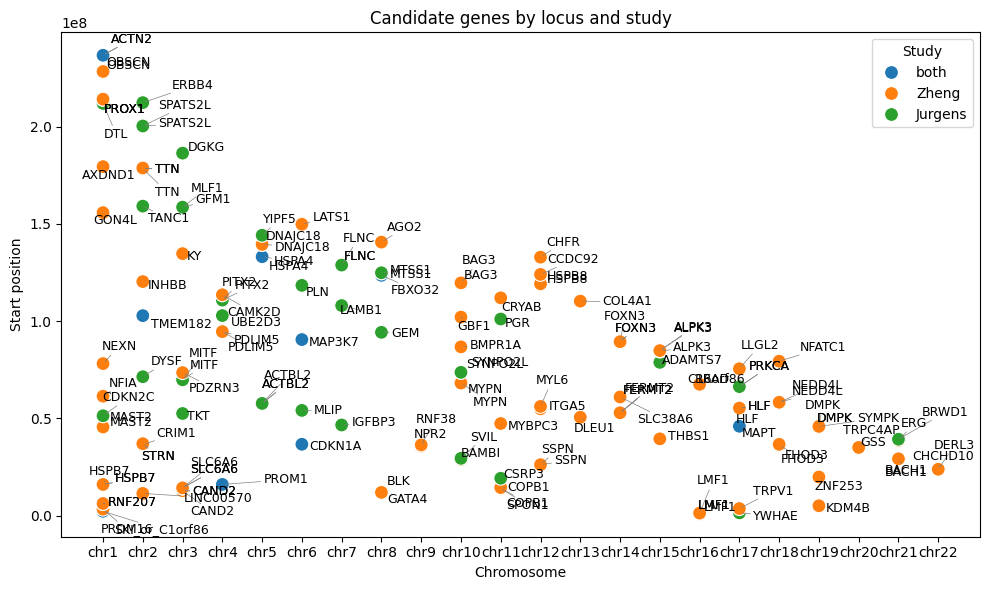

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=unique_combined_GWAS_loci_df,
    x="chr",
    y="start",
    hue="study",
    s=100
)

# Collect text labels
texts = []
for i, row in unique_combined_GWAS_loci_df.iterrows():
    texts.append(
        plt.text(
            row["chr"],
            row["start"],
            row["candidate_gene"],
            fontsize=9
        )
    )

# Adjust text to repel overlaps
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.xlabel("Chromosome")
plt.ylabel("Start position")
plt.title("Candidate genes by locus and study")
plt.legend(title="Study")
plt.tight_layout()
plt.show()

### Save as bed file

In [37]:
GWAS_loci_bed = unique_combined_GWAS_loci_df[["chr", "start", "end"]]
GWAS_loci_bed.to_csv("GWAS_loci.bed", header=False, index=None, sep = "\t")

### For plink, we will want the format of `<chr>:start-end` without any `"chr"`

In [38]:
unique_combined_GWAS_loci_df["plink_name"] = unique_combined_GWAS_loci_df.apply(
    lambda row: f"{row['chr'].replace('chr','')}:{row['start']}" 
                if row["start"] == row["end"] 
                else f"{row['chr'].replace('chr','')}:{row['start']},{row['chr'].replace('chr','')}:{row['end']}",
    axis=1
)

# Save as CSV without header/index
unique_combined_GWAS_loci_df['plink_name'].to_csv(
    "hg38_combined_unique_DCM_SNPs.csv", 
    header=False, 
    index=False
)

In [39]:
unique_combined_GWAS_loci_df.to_csv("03_combined_SNP_list_with_effector_genes.csv")